# Walmart Sales Data Analysis

## Project Overview
This project analyzes Walmart's weekly sales data to uncover patterns, trends, and actionable business insights.

## Dataset Information
- **Source**: Walmart Sales Forecasting Dataset
- **Time Period**: February 2010 - October 2012
- **Records**: 6,435 weekly sales records
- **Stores**: 45 stores

## Columns Description
| Column | Description |
|--------|-------------|
| Store | Store number (1-45) |
| Date | Week of sales |
| Weekly_Sales | Sales for that week |
| Holiday_Flag | 1 = Holiday week, 0 = Non-holiday |
| Temperature | Temperature on sale day |
| Fuel_Price | Regional fuel cost |
| CPI | Consumer Price Index |
| Unemployment | Regional unemployment rate |

## Goals
1. Understand sales patterns over time
2. Identify top and bottom performing stores
3. Measure holiday impact on sales
4. Find seasonal trends
5. Analyze economic factors affecting sales
6. Provide actionable recommendations

---# 🛒 Walmart Sales Data Analysis

## Project Overview
This project analyzes Walmart's weekly sales data to uncover patterns, trends, and actionable business insights.

## Dataset Information
- **Source**: Walmart Sales Forecasting Dataset
- **Time Period**: February 2010 - October 2012
- **Records**: 6,435 weekly sales records
- **Stores**: 45 stores

## Columns Description
| Column | Description |
|--------|-------------|
| Store | Store number (1-45) |
| Date | Week of sales |
| Weekly_Sales | Sales for that week |
| Holiday_Flag | 1 = Holiday week, 0 = Non-holiday |
| Temperature | Temperature on sale day |
| Fuel_Price | Regional fuel cost |
| CPI | Consumer Price Index |
| Unemployment | Regional unemployment rate |

## Goals
1. Understand sales patterns over time
2. Identify top and bottom performing stores
3. Measure holiday impact on sales
4. Find seasonal trends
5. Analyze economic factors affecting sales
6. Provide actionable recommendations

---

# Importing Libraries

In [1]:
import pandas as pd          # For dataframes and data operations
import numpy as np           # For numerical operations

# Data visualization
import matplotlib.pyplot as plt  # For creating plots
import seaborn as sns            # For enhanced visualizations

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Set up professional plotting style
sns.set_style("whitegrid")                    # Grid background
plt.rcParams['figure.figsize'] = (12, 6)      # Default figure size
plt.rcParams['font.size'] = 11                # Default font size
plt.rcParams['axes.titlesize'] = 14           # Title font size
plt.rcParams['axes.labelsize'] = 12           # Axis label font size

## Loading Dataset

In [ ]:
df = pd.read_csv(r'../data/Walmart_Sales.csv') 

# Displaying basic information about the dataset
print("DATASET OVERVIEW")
print("-" * 100)

# Showing first 5 rows to understand data structure
df.head()


DATASET OVERVIEW
----------------------------------------------------------------------------------------------------


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [52]:
# Show dataset shape (rows and columns)
print(f"Dataset shape: {df.shape}")
print("-" * 100)

# Show column names
print("Columns:", df.columns.tolist())
print("-" * 100)

# Show data types
print(df.dtypes)
print("-" * 100)

# Quick data quality check
print("Null values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("-" * 100)


Dataset shape: (6435, 8)
----------------------------------------------------------------------------------------------------
Columns: ['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
----------------------------------------------------------------------------------------------------
Store                    int64
Date            datetime64[us]
Weekly_Sales           float64
Holiday_Flag             int64
Temperature            float64
Fuel_Price             float64
CPI                    float64
Unemployment           float64
dtype: object
----------------------------------------------------------------------------------------------------
Null values: 0
Duplicate rows: 0
----------------------------------------------------------------------------------------------------


## Data Cleaning

In [53]:
print("DATA CLEANING")
print("-" * 100)

# Converting Date column 
print("\nSTEP 1: Converting Date column...")
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
print(f" Date range: {df['Date'].min().strftime('%Y-%m-%d')} to {df['Date'].max().strftime('%Y-%m-%d')}")

print("\n" + "-" * 100)

# Check for negative sales 
print("Checking for negative sales values...")
negative_sales = (df['Weekly_Sales'] < 0).sum()
if negative_sales == 0:
    print("   All sales values are positive!")
else:
    print(f"   Found {negative_sales} rows with negative sales")
    
print("\n" + "-" * 100)

# Validate Holiday_Flag
print("Validating Holiday_Flag column...")
valid_holiday = df['Holiday_Flag'].isin([0, 1]).all()
if valid_holiday:
    print("   Holiday_Flag contains only 0 and 1")
    holiday_count = df['Holiday_Flag'].sum()
    print(f"   Holiday weeks: {holiday_count} out of {len(df)} ({holiday_count/len(df)*100:.1f}%)")
    
print("\n" + "-" * 100)

# Check for outliers in sales
print("\nChecking for sales outliers...")
Q1 = df['Weekly_Sales'].quantile(0.25)
Q3 = df['Weekly_Sales'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = ((df['Weekly_Sales'] < lower_bound) | (df['Weekly_Sales'] > upper_bound)).sum()
print(f"   Found {outliers} potential outlier sales records")
print(f"   Normal sales range: ${lower_bound:,.0f} - ${upper_bound:,.0f}")

print("\n" + "-" * 100)


DATA CLEANING
----------------------------------------------------------------------------------------------------

STEP 1: Converting Date column...
 Date range: 2010-02-05 to 2012-10-26

----------------------------------------------------------------------------------------------------
Checking for negative sales values...
   All sales values are positive!

----------------------------------------------------------------------------------------------------
Validating Holiday_Flag column...
   Holiday_Flag contains only 0 and 1
   Holiday weeks: 450 out of 6435 (7.0%)

----------------------------------------------------------------------------------------------------

Checking for sales outliers...
   Found 34 potential outlier sales records
   Normal sales range: $-746,863 - $2,720,371

----------------------------------------------------------------------------------------------------


## Feature Engineering

In [54]:
print("FEATURE ENGINEERING")
print("-" * 100)

# Create a copy of the cleaned dataset to avoid modifying the original directly
df_clean = df.copy()

# Extracting date components
df_clean['Year'] = df_clean['Date'].dt.year        # Extract year
df_clean['Month'] = df_clean['Date'].dt.month      # Extract month number (1–12)
df_clean['Day'] = df_clean['Date'].dt.day          # Extract day of the month
df_clean['Week'] = df_clean['Date'].dt.isocalendar().week  # Extract ISO week number
df_clean['Quarter'] = df_clean['Date'].dt.quarter  # Extract quarter (1–4)

# Create Season column
print("\nCreating Season column...")

def get_season(month):
    """Convert month number to season name"""
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:  # Months 9, 10, 11
        return 'Fall'

df_clean['Season'] = df_clean['Month'].apply(get_season)

# Create Sales Category column
# Use percentiles to categorize sales into High, Medium, Low
sales_percentiles = df_clean['Weekly_Sales'].quantile([0.33, 0.67])

def get_sales_category(sales):
    """Categorize sales into High, Medium, or Low based on percentiles"""
    if sales >= sales_percentiles[0.67]:
        return 'High'
    elif sales >= sales_percentiles[0.33]:
        return 'Medium'
    else:
        return 'Low'

df_clean['Sales_Category'] = df_clean['Weekly_Sales'].apply(get_sales_category)

# Print thresholds for clarity
print(f"     - High: > ${sales_percentiles[0.67]:,.0f}")
print(f"     - Medium: ${sales_percentiles[0.33]:,.0f} - ${sales_percentiles[0.67]:,.0f}")
print(f"     - Low: < ${sales_percentiles[0.33]:,.0f}")

# Create DayOfWeek column
# Note: Since data is weekly, all dates are Fridays
df_clean['DayOfWeek'] = df_clean['Date'].dt.day_name()
print(f" All dates are {df_clean['DayOfWeek'].iloc[0]}s")

# Display final columns
print("\n" + "-" * 100)
print("FINAL COLUMNS:")
for col in df_clean.columns:
    print(f"   {col}")

# Save cleaned dataset to outputs
df_clean.to_csv('../outputs/walmart_cleaned.csv', index=False)

print("-" * 100)

FEATURE ENGINEERING
----------------------------------------------------------------------------------------------------

Creating Season column...
     - High: > $1,285,496
     - Medium: $663,409 - $1,285,496
     - Low: < $663,409
 All dates are Fridays

----------------------------------------------------------------------------------------------------
FINAL COLUMNS:
   Store
   Date
   Weekly_Sales
   Holiday_Flag
   Temperature
   Fuel_Price
   CPI
   Unemployment
   Year
   Month
   Day
   Week
   Quarter
   Season
   Sales_Category
   DayOfWeek
----------------------------------------------------------------------------------------------------


## Basic Statistical Analysis

In [62]:
print("BASIC STATISTICAL ANALYSIS")
print("-" * 100)

# Overall Sales Metrics
print("OVERALL SALES METRICS:")

total_sales = df_clean['Weekly_Sales'].sum()
avg_sales = df_clean['Weekly_Sales'].mean()
median_sales = df_clean['Weekly_Sales'].median()
max_sales = df_clean['Weekly_Sales'].max()
min_sales = df_clean['Weekly_Sales'].min()
std_sales = df_clean['Weekly_Sales'].std()

print(f"   Total Sales (all time):     ${total_sales:,.2f} (${total_sales/1e9:.2f}B)")
print(f"   Average Weekly Sales:       ${avg_sales:,.2f}")
print(f"   Median Weekly Sales:        ${median_sales:,.2f}")
print(f"   Maximum Weekly Sales:       ${max_sales:,.2f}")
print(f"   Minimum Weekly Sales:       ${min_sales:,.2f}")
print(f"   Standard Deviation:         ${std_sales:,.2f}")

# Sales by Year
print("\nSALES BY YEAR:")
print("-" * 100)

yearly_sales = df_clean.groupby('Year')['Weekly_Sales'].sum()
for year, sales in yearly_sales.items():
    print(f"   {year}:  ${sales:,.2f} (${sales/1e6:.1f}M)")

# Year-over-year growth
years = sorted(yearly_sales.index)
for i in range(1, len(years)):
    growth = ((yearly_sales[years[i]] - yearly_sales[years[i-1]]) / yearly_sales[years[i-1]]) * 100
    print(f"\n Growth {years[i-1]} → {years[i]}: {growth:+.1f}%")

# Sales by Quarter
print("SALES BY QUARTER:")
print("-" * 100)

quarterly_sales = df_clean.groupby('Quarter')['Weekly_Sales'].mean()
for quarter, sales in quarterly_sales.items():
     # Add bar visualization scaled by sales
    print(f"   Q{quarter}:  ${sales:,.0f} ")

# Statistical Summary
print("\nSTATISTICAL SUMMARY (Numeric Columns):")
print("-" * 100)
print(df_clean[['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']].describe().round(2))

print("-" * 100)
print("BASIC STATISTICS COMPLETE!")


BASIC STATISTICAL ANALYSIS
----------------------------------------------------------------------------------------------------
OVERALL SALES METRICS:
   Total Sales (all time):     $6,737,218,987.11 ($6.74B)
   Average Weekly Sales:       $1,046,964.88
   Median Weekly Sales:        $960,746.04
   Maximum Weekly Sales:       $3,818,686.45
   Minimum Weekly Sales:       $209,986.25
   Standard Deviation:         $564,366.62

SALES BY YEAR:
----------------------------------------------------------------------------------------------------
   2010:  $2,288,886,120.41 ($2288.9M)
   2011:  $2,448,200,007.35 ($2448.2M)
   2012:  $2,000,132,859.35 ($2000.1M)

 Growth 2010 → 2011: +7.0%

 Growth 2011 → 2012: -18.3%
SALES BY QUARTER:
----------------------------------------------------------------------------------------------------
   Q1:  $1,006,136 
   Q2:  $1,040,806 
   Q3:  $1,023,251 
   Q4:  $1,128,774 

STATISTICAL SUMMARY (Numeric Columns):
------------------------------------------

## STORE PERFORMANCE ANALYSIS

###  a:Store performance analysis(Totals)

In [73]:
print("STORE PERFORMANCE ANALYSIS")
print("-" * 100)

# Total Sales by Store
# Calculate total sales per store and sort in descending order
store_total = df_clean.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False)

print("\nTOP 5 STORES:")
print("-" * 100)
for i, (store, sales) in enumerate(store_total.head(5).items(), 1):
    print(f"   {i}. Store {store}:  ${sales:,.2f} (${sales/1e6:.1f}M)")

print("\nBOTTOM 5 STORES:")
print("-" * 100)
for i, (store, sales) in enumerate(store_total.tail(5).items(), 1):
    print(f"   {i}. Store {store}:  ${sales:,.2f} (${sales/1e6:.1f}M)")

print("-" * 100)
print("PART 1 COMPLETE: Totals")


STORE PERFORMANCE ANALYSIS
----------------------------------------------------------------------------------------------------

TOP 5 STORES:
----------------------------------------------------------------------------------------------------
   1. Store 20:  $301,397,792.46 ($301.4M)
   2. Store 4:  $299,543,953.38 ($299.5M)
   3. Store 14:  $288,999,911.34 ($289.0M)
   4. Store 13:  $286,517,703.80 ($286.5M)
   5. Store 2:  $275,382,440.98 ($275.4M)

BOTTOM 5 STORES:
----------------------------------------------------------------------------------------------------
   1. Store 38:  $55,159,626.42 ($55.2M)
   2. Store 36:  $53,412,214.97 ($53.4M)
   3. Store 5:  $45,475,688.90 ($45.5M)
   4. Store 44:  $43,293,087.84 ($43.3M)
   5. Store 33:  $37,160,221.96 ($37.2M)
----------------------------------------------------------------------------------------------------
PART 1 COMPLETE: Totals


###  b:Store performance analysis (Concentration & Averages)

In [71]:
# CELL 7b: STORE PERFORMANCE ANALYSIS (Concentration & Averages)
print("STORE PERFORMANCE ANALYSIS")
print("-" * 100)

# Sales Concentration
# Calculate percentage contribution of top stores to overall sales
top3_pct = (store_total.head(3).sum() / store_total.sum()) * 100
top5_pct = (store_total.head(5).sum() / store_total.sum()) * 100
top10_pct = (store_total.head(10).sum() / store_total.sum()) * 100

print("\nSALES CONCENTRATION:")
print("-" * 100)
print(f"   Top 3 stores contribute: {top3_pct:.1f}% of total sales")
print(f"   Top 5 stores contribute: {top5_pct:.1f}% of total sales")
print(f"   Top 10 stores contribute: {top10_pct:.1f}% of total sales")

# Average Weekly Sales by Store
# Calculate average weekly sales per store
store_avg = df_clean.groupby('Store')['Weekly_Sales'].mean().sort_values(ascending=False)

print("\nAVERAGE WEEKLY SALES BY STORE:")
print("-" * 100)
print("TOP 5 STORES (Weekly Average):")
for i, (store, avg) in enumerate(store_avg.head(5).items(), 1):
    print(f"   {i}. Store {store}:  ${avg:,.0f} per week")

print("-" * 100)
print("PART 2 COMPLETE: Concentration & Averages")


STORE PERFORMANCE ANALYSIS
----------------------------------------------------------------------------------------------------

SALES CONCENTRATION:
----------------------------------------------------------------------------------------------------
   Top 3 stores contribute: 13.2% of total sales
   Top 5 stores contribute: 21.5% of total sales
   Top 10 stores contribute: 39.1% of total sales

AVERAGE WEEKLY SALES BY STORE:
----------------------------------------------------------------------------------------------------
TOP 5 STORES (Weekly Average):
   1. Store 20:  $2,107,677 per week
   2. Store 4:  $2,094,713 per week
   3. Store 14:  $2,020,978 per week
   4. Store 13:  $2,003,620 per week
   5. Store 2:  $1,925,751 per week
----------------------------------------------------------------------------------------------------
PART 2 COMPLETE: Concentration & Averages


### c: Store performance analysis (Variability & Summary)

In [72]:
print("STORE PERFORMANCE ANALYSIS")
print("-" * 100)

# Sales Variability (Risk)
# Calculate standard deviation of weekly sales per store
store_std = df_clean.groupby('Store')['Weekly_Sales'].std().sort_values(ascending=False)

print("\nSALES VARIABILITY (Standard Deviation):")
print("-" * 100)
print("MOST VOLATILE STORES (highest unpredictability):")
for i, (store, std) in enumerate(store_std.head(3).items(), 1):
    print(f"   {i}. Store {store}:  ±${std:,.0f}")

print("\nMOST CONSISTENT STORES (lowest variability):")
print("-" * 100)
for i, (store, std) in enumerate(store_std.tail(3).items(), 1):
    print(f"   {i}. Store {store}:  ±${std:,.0f}")

# Store Performance Summary
# Identify best and worst stores by total and average sales
best_store = store_total.idxmax()
worst_store = store_total.idxmin()
best_avg = store_avg.idxmax()
worst_avg = store_avg.idxmin()

print("\nSTORE PERFORMANCE SUMMARY:")
print("-" * 100)
print(f"   Highest Total Sales:     Store {best_store}")
print(f"   Lowest Total Sales:      Store {worst_store}")
print(f"   Highest Average Sales:   Store {best_avg}")
print(f"   Lowest Average Sales:    Store {worst_avg}")

# Sales Gap
# Compare best store vs worst store total sales
gap = store_total[best_store] / store_total[worst_store]
print(f"\n   Sales Gap (Best vs Worst): {gap:.1f}x difference")

print("-" * 100)
print("PART 3 COMPLETE: Variability & Summary")


STORE PERFORMANCE ANALYSIS
----------------------------------------------------------------------------------------------------

SALES VARIABILITY (Standard Deviation):
----------------------------------------------------------------------------------------------------
MOST VOLATILE STORES (highest unpredictability):
   1. Store 14:  ±$317,570
   2. Store 10:  ±$302,262
   3. Store 20:  ±$275,901

MOST CONSISTENT STORES (lowest variability):
----------------------------------------------------------------------------------------------------
   1. Store 33:  ±$24,133
   2. Store 30:  ±$22,810
   3. Store 37:  ±$21,837

STORE PERFORMANCE SUMMARY:
----------------------------------------------------------------------------------------------------
   Highest Total Sales:     Store 20
   Lowest Total Sales:      Store 33
   Highest Average Sales:   Store 20
   Lowest Average Sales:    Store 33

   Sales Gap (Best vs Worst): 8.1x difference
---------------------------------------------------

## HOLIDAY IMPACT ANALYSIS

### a: Holiday impact analysis (Holiday vs Non-Holiday Sales)

In [74]:
print("HOLIDAY IMPACT ANALYSIS")
print("-" * 100)

# Separate holiday and non-holiday data
holiday_data = df_clean[df_clean['Holiday_Flag'] == 1]
non_holiday_data = df_clean[df_clean['Holiday_Flag'] == 0]

# Compare average weekly sales
holiday_avg = holiday_data['Weekly_Sales'].mean()
non_holiday_avg = non_holiday_data['Weekly_Sales'].mean()

print("\nSALES: HOLIDAY VS NON-HOLIDAY")
print("-" * 100)
print(f"   Average Sales - Holiday Weeks:    ${holiday_avg:,.2f}")
print(f"   Average Sales - Non-Holiday:      ${non_holiday_avg:,.2f}")

# Calculate holiday sales lift percentage
lift = ((holiday_avg - non_holiday_avg) / non_holiday_avg) * 100
print(f"\n   Holiday Sales Lift:               +{lift:.1f}%")

print("-" * 100)
print("PART 1 COMPLETE: Holiday vs Non-Holiday Sales")


HOLIDAY IMPACT ANALYSIS
----------------------------------------------------------------------------------------------------

SALES: HOLIDAY VS NON-HOLIDAY
----------------------------------------------------------------------------------------------------
   Average Sales - Holiday Weeks:    $1,122,887.89
   Average Sales - Non-Holiday:      $1,041,256.38

   Holiday Sales Lift:               +7.8%
----------------------------------------------------------------------------------------------------
PART 1 COMPLETE: Holiday vs Non-Holiday Sales


### b: Holiday impact analysis (Frequency & Best Week)

In [75]:
print("HOLIDAY IMPACT ANALYSIS")
print("-" * 100)

# Count holiday weeks
holiday_count = holiday_data.shape[0]
total_weeks = df_clean.shape[0]

print("\nHOLIDAY FREQUENCY")
print("-" * 100)
print(f"   Holiday weeks: {holiday_count} out of {total_weeks} ({holiday_count/total_weeks*100:.1f}%)")

# Identify best holiday week (highest sales)
best_holiday = holiday_data.loc[holiday_data['Weekly_Sales'].idxmax()]

print("\nBEST HOLIDAY WEEK")
print("-" * 100)
print(f"   Date:        {best_holiday['Date'].strftime('%Y-%m-%d')}")
print(f"   Store:       {best_holiday['Store']}")
print(f"   Sales:       ${best_holiday['Weekly_Sales']:,.2f} (${best_holiday['Weekly_Sales']/1e6:.1f}M)")
print(f"   Temperature: {best_holiday['Temperature']:.1f}°F")

print("-" * 100)
print("PART 2 COMPLETE: Frequency & Best Week")


HOLIDAY IMPACT ANALYSIS
----------------------------------------------------------------------------------------------------

HOLIDAY FREQUENCY
----------------------------------------------------------------------------------------------------
   Holiday weeks: 450 out of 6435 (7.0%)

BEST HOLIDAY WEEK
----------------------------------------------------------------------------------------------------
   Date:        2011-11-25
   Store:       4
   Sales:       $3,004,702.33 ($3.0M)
   Temperature: 48.0°F
----------------------------------------------------------------------------------------------------
PART 2 COMPLETE: Frequency & Best Week


### c: Holiday impact analysis (Store Impact & Summary)

In [76]:
print("HOLIDAY IMPACT ANALYSIS")
print("-" * 80)

# Calculate holiday lift per store
store_holiday_impact = []
for store in df_clean['Store'].unique():
    store_data = df_clean[df_clean['Store'] == store]
    holiday_s = store_data[store_data['Holiday_Flag'] == 1]['Weekly_Sales'].mean()
    non_holiday_s = store_data[store_data['Holiday_Flag'] == 0]['Weekly_Sales'].mean()
    if pd.notna(holiday_s) and pd.notna(non_holiday_s) and non_holiday_s > 0:
        lift_pct = ((holiday_s - non_holiday_s) / non_holiday_s) * 100
        store_holiday_impact.append((store, lift_pct))

# Sort by lift percentage
store_holiday_impact.sort(key=lambda x: x[1], reverse=True)

print("\nHOLIDAY IMPACT BY STORE (Top 5)")
print("-" * 80)
for i, (store, lift_pct) in enumerate(store_holiday_impact[:5], 1):
    print(f"   {i}. Store {store}: +{lift_pct:.1f}%")

print("\nStores with LOWEST holiday lift:")
print("-" * 80)
for i, (store, lift_pct) in enumerate(store_holiday_impact[-5:], 1):
    print(f"   {i}. Store {store}: {lift_pct:+.1f}%")

# Summary of key insights
print("\nKEY HOLIDAY INSIGHTS")
print("-" * 80)
print(f"   • Holiday weeks generate {lift:.1f}% more sales on average")
print(f"   • Best holiday week: {best_holiday['Date'].strftime('%b %d, %Y')}")
print(f"   • Store {best_holiday['Store']} had the highest holiday sales")
print(f"   • {holiday_count} holiday weeks in the dataset")

print("-" * 80)
print("PART 3 COMPLETE: Store Impact & Summary")


HOLIDAY IMPACT ANALYSIS
--------------------------------------------------------------------------------

HOLIDAY IMPACT BY STORE (Top 5)
--------------------------------------------------------------------------------
   1. Store 7: +19.4%
   2. Store 35: +18.3%
   3. Store 15: +14.5%
   4. Store 5: +14.2%
   5. Store 12: +13.9%

Stores with LOWEST holiday lift:
--------------------------------------------------------------------------------
   1. Store 30: -0.4%
   2. Store 38: -1.2%
   3. Store 36: -1.7%
   4. Store 37: -2.4%
   5. Store 44: -2.4%

KEY HOLIDAY INSIGHTS
--------------------------------------------------------------------------------
   • Holiday weeks generate 7.8% more sales on average
   • Best holiday week: Nov 25, 2011
   • Store 4 had the highest holiday sales
   • 450 holiday weeks in the dataset
--------------------------------------------------------------------------------
PART 3 COMPLETE: Store Impact & Summary


 ## SEASONAL PATTERN ANALYSIS

### a: Seasonal pattern analysi (Monthly Sales)

In [85]:
# CELL 9a: SEASONAL PATTERN ANALYSIS (Monthly Sales)
print("SEASONAL PATTERN ANALYSIS")
print("-" * 80)

# Monthly Sales Pattern
# Calculate average weekly sales per month
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

monthly_sales = df_clean.groupby('Month')['Weekly_Sales'].mean()

print("\nMONTHLY SALES PATTERN")
print("-" * 80)
for month in range(1, 13):
    bar_length = int(monthly_sales[month] / 30000)
    bar = "█" * bar_length
    marker = ""
    if month == monthly_sales.idxmax():
        marker = " ← BEST"
    elif month == monthly_sales.idxmin():
        marker = " ← WORST"
    print(f"   {month_names[month-1]}:  ${monthly_sales[month]:,.0f}  {bar}{marker}")

# Identify best and worst months
best_month = monthly_sales.idxmax()
worst_month = monthly_sales.idxmin()
best_month_name = month_names[best_month-1]
worst_month_name = month_names[worst_month-1]

print(f"\n   Best Month:  {best_month_name} (${monthly_sales[best_month]:,.0f})")
print(f"   Worst Month: {worst_month_name} (${monthly_sales[worst_month]:,.0f})")
print(f"   Difference:  {((monthly_sales[best_month] - monthly_sales[worst_month]) / monthly_sales[worst_month] * 100):.1f}% higher")

print("-" * 80)
print("PART 1 COMPLETE: Monthly Sales Pattern")


SEASONAL PATTERN ANALYSIS
--------------------------------------------------------------------------------

MONTHLY SALES PATTERN
--------------------------------------------------------------------------------
   Jan:  $923,885  ██████████████████████████████ ← WORST
   Feb:  $1,053,200  ███████████████████████████████████
   Mar:  $1,013,309  █████████████████████████████████
   Apr:  $1,026,762  ██████████████████████████████████
   May:  $1,031,714  ██████████████████████████████████
   Jun:  $1,064,325  ███████████████████████████████████
   Jul:  $1,031,748  ██████████████████████████████████
   Aug:  $1,048,017  ██████████████████████████████████
   Sep:  $989,335  ████████████████████████████████
   Oct:  $999,632  █████████████████████████████████
   Nov:  $1,147,266  ██████████████████████████████████████
   Dec:  $1,281,864  ██████████████████████████████████████████ ← BEST

   Best Month:  Dec ($1,281,864)
   Worst Month: Jan ($923,885)
   Difference:  38.7% higher
--------

### b: Seasonal pattern analysi (Seasonal & Quarterly)

In [86]:
# CELL 9b: SEASONAL PATTERN ANALYSIS (Seasonal & Quarterly)
print("SEASONAL PATTERN ANALYSIS")
print("-" * 80)

# Seasonal Sales Pattern
print("\nSEASONAL SALES PATTERN")
print("-" * 80)
season_order = ['Winter', 'Spring', 'Summer', 'Fall']
seasonal_sales = df_clean.groupby('Season')['Weekly_Sales'].mean()

for season in season_order:
    bar = "█" * int(seasonal_sales[season] / 30000)
    print(f"   {season}:  ${seasonal_sales[season]:,.0f}  {bar}")

# Quarterly Sales Pattern
print("\nQUARTERLY SALES PATTERN")
print("-" * 80)
quarterly_sales = df_clean.groupby('Quarter')['Weekly_Sales'].mean()
for quarter in range(1, 5):
    bar = "█" * int(quarterly_sales[quarter] / 30000)
    print(f"   Q{quarter}:  ${quarterly_sales[quarter]:,.0f}  {bar}")

# Q4 vs Q1 comparison
q4_avg = quarterly_sales[4]
q1_avg = quarterly_sales[1]
q4_vs_q1 = ((q4_avg - q1_avg) / q1_avg) * 100
print(f"\n   Q4 is {q4_vs_q1:.1f}% higher than Q1")

print("-" * 80)
print("PART 2 COMPLETE: Seasonal & Quarterly Sales")


SEASONAL PATTERN ANALYSIS
--------------------------------------------------------------------------------

SEASONAL SALES PATTERN
--------------------------------------------------------------------------------
   Winter:  $1,094,937  ████████████████████████████████████
   Spring:  $1,023,801  ██████████████████████████████████
   Summer:  $1,047,623  ██████████████████████████████████
   Fall:  $1,030,432  ██████████████████████████████████

QUARTERLY SALES PATTERN
--------------------------------------------------------------------------------
   Q1:  $1,006,136  █████████████████████████████████
   Q2:  $1,040,806  ██████████████████████████████████
   Q3:  $1,023,251  ██████████████████████████████████
   Q4:  $1,128,774  █████████████████████████████████████

   Q4 is 12.2% higher than Q1
--------------------------------------------------------------------------------
PART 2 COMPLETE: Seasonal & Quarterly Sales


### c: Seasonal pattern analysis (Year-over-Year & Summary)

In [87]:
print("SEASONAL PATTERN ANALYSIS")
print("-" * 80)

# Year-over-Year Monthly Comparison
print("\nYEAR-OVER-YEAR MONTHLY COMPARISON")
print("-" * 80)

# Create pivot table of monthly sales by year
monthly_by_year = df_clean.pivot_table(
    values='Weekly_Sales', 
    index='Month', 
    columns='Year', 
    aggfunc='mean'
)

print("Average Weekly Sales by Month and Year:")
print(monthly_by_year.round(0).to_string())

# Calculate year-over-year change for each month
print("\nYear-over-Year Change (%):")
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

for month in range(1, 13):
    if 2010 in monthly_by_year.columns and 2011 in monthly_by_year.columns:
        yoy_change = ((monthly_by_year.loc[month, 2011] - monthly_by_year.loc[month, 2010]) / monthly_by_year.loc[month, 2010]) * 100
        print(f"   {month_names[month-1]}:  {yoy_change:+.1f}%")

# Summary of key seasonal insights
print("\nKEY SEASONAL INSIGHTS")
print("-" * 80)
print(f"   • Best month: {best_month_name} (${monthly_sales[best_month]:,.0f})")
print(f"   • Worst month: {worst_month_name} (${monthly_sales[worst_month]:,.0f})")
print(f"   • Best season: {seasonal_sales.idxmax()} (${seasonal_sales.max():,.0f})")
print(f"   • Worst season: {seasonal_sales.idxmin()} (${seasonal_sales.min():,.0f})")
print(f"   • Q4 (Oct-Dec) is the strongest quarter")
print(f"   • Q1 (Jan-Mar) is the weakest quarter")

print("-" * 80)
print("PART 3 COMPLETE: Year-over-Year & Summary")


SEASONAL PATTERN ANALYSIS
--------------------------------------------------------------------------------

YEAR-OVER-YEAR MONTHLY COMPARISON
--------------------------------------------------------------------------------
Average Weekly Sales by Month and Year:
Year        2010       2011       2012
Month                                 
1            NaN   909466.0   938303.0
2      1057405.0  1035174.0  1067020.0
3      1010666.0   996425.0  1028932.0
4      1028499.0  1006784.0  1049561.0
5      1037283.0  1009156.0  1048703.0
6      1068034.0  1054297.0  1069379.0
7      1033689.0  1021828.0  1041719.0
8      1042445.0  1047774.0  1052670.0
9       984822.0   981546.0  1003586.0
10      965164.0  1018118.0  1024232.0
11     1126963.0  1167569.0        NaN
12     1283380.0  1280347.0        NaN

Year-over-Year Change (%):
   Jan:  +nan%
   Feb:  -2.1%
   Mar:  -1.4%
   Apr:  -2.1%
   May:  -2.7%
   Jun:  -1.3%
   Jul:  -1.1%
   Aug:  +0.5%
   Sep:  -0.3%
   Oct:  +5.5%
   Nov:  +3.6

## ECONOMIC FACTOR CORRELATION ANALYSIS

### a: Correlation Matrix & Weekly Sales Correlations

In [88]:
print("-" * 100)

# Select numeric columns for correlation
numeric_cols = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
correlation_matrix = df_clean[numeric_cols].corr()

# Display correlations with Weekly_Sales
print("\nCORRELATION WITH WEEKLY SALES")
print("-" * 100)

# Function to interpret correlation strength and direction
def interpret_correlation(corr_value):
    if abs(corr_value) >= 0.5:
        strength = "Strong"
    elif abs(corr_value) >= 0.3:
        strength = "Moderate"
    elif abs(corr_value) >= 0.1:
        strength = "Weak"
    else:
        strength = "Very Weak"
    direction = "positive" if corr_value > 0 else "negative"
    return strength, direction

# Print correlation values with interpretation
for col in numeric_cols[1:]:
    corr_value = correlation_matrix.loc['Weekly_Sales', col]
    strength, direction = interpret_correlation(corr_value)
    print(f"   {col}: {corr_value:.3f} ({strength} {direction})")

print("-" * 100)
print("PART 1 COMPLETE: Correlation Matrix")


----------------------------------------------------------------------------------------------------

CORRELATION WITH WEEKLY SALES
----------------------------------------------------------------------------------------------------
   Temperature: -0.064 (Very Weak negative)
   Fuel_Price: 0.009 (Very Weak positive)
   CPI: -0.073 (Very Weak negative)
   Unemployment: -0.106 (Weak negative)
----------------------------------------------------------------------------------------------------
PART 1 COMPLETE: Correlation Matrix


### b: Detailed Factor Analysis

In [89]:
print("-" * 100)

# Temperature analysis
temp_corr = correlation_matrix.loc['Weekly_Sales', 'Temperature']
print("\nTEMPERATURE ANALYSIS")
print("-" * 100)
if temp_corr > 0:
    print("   • Higher temperatures are weakly associated with higher sales")
else:
    print("   • Higher temperatures are weakly associated with lower sales")
print("   • Temperature alone is not a strong predictor of sales")

# Fuel Price analysis
fuel_corr = correlation_matrix.loc['Weekly_Sales', 'Fuel_Price']
print("\nFUEL PRICE ANALYSIS")
print("-" * 100)
if abs(fuel_corr) < 0.1:
    print("   • Very weak correlation with sales")
    print("   • Fuel prices have minimal direct impact on store sales")
else:
    print("   • Fuel prices show some relationship with sales")

# CPI analysis
cpi_corr = correlation_matrix.loc['Weekly_Sales', 'CPI']
print("\nCPI ANALYSIS")
print("-" * 100)
if cpi_corr > 0:
    print("   • Moderate positive correlation")
    print("   • Sales tend to increase when CPI increases")
else:
    print("   • Negative correlation with sales")

# Unemployment analysis
unemp_corr = correlation_matrix.loc['Weekly_Sales', 'Unemployment']
print("\nUNEMPLOYMENT ANALYSIS")
print("-" * 100)
if unemp_corr < 0:
    print("   • Moderate negative correlation")
    print("   • Sales decrease when unemployment rises")
    print("   • Most significant economic factor affecting sales")
else:
    print("   • Positive correlation with sales")

print("-" * 100)
print("PART 2 COMPLETE: Detailed Factor Analysis")


----------------------------------------------------------------------------------------------------

TEMPERATURE ANALYSIS
----------------------------------------------------------------------------------------------------
   • Higher temperatures are weakly associated with lower sales
   • Temperature alone is not a strong predictor of sales

FUEL PRICE ANALYSIS
----------------------------------------------------------------------------------------------------
   • Very weak correlation with sales
   • Fuel prices have minimal direct impact on store sales

CPI ANALYSIS
----------------------------------------------------------------------------------------------------
   • Negative correlation with sales

UNEMPLOYMENT ANALYSIS
----------------------------------------------------------------------------------------------------
   • Moderate negative correlation
   • Sales decrease when unemployment rises
   • Most significant economic factor affecting sales
--------------------------

### c: Grouped Sales by Economic Categories & Summary

In [90]:
print("ECONOMIC FACTOR CORRELATION ANALYSIS")
print("-" * 100)

# Group by unemployment levels
print("\nSALES BY UNEMPLOYMENT LEVEL")
print("-" * 100)

def unemployment_category(rate):
    if rate < 6:
        return 'Low (<6%)'
    elif rate < 7:
        return 'Medium (6-7%)'
    elif rate < 8:
        return 'High (7-8%)'
    else:
        return 'Very High (>8%)'

df_clean['Unemployment_Category'] = df_clean['Unemployment'].apply(unemployment_category)
unemp_sales = df_clean.groupby('Unemployment_Category')['Weekly_Sales'].mean()
unemp_order = ['Low (<6%)', 'Medium (6-7%)', 'High (7-8%)', 'Very High (>8%)']

for category in unemp_order:
    if category in unemp_sales.index:
        sales = unemp_sales[category]
        bar = "█" * int(sales / 30000)
        print(f"   {category}:  ${sales:,.0f}  {bar}")

# Group by CPI levels
print("\nSALES BY CPI LEVEL")
print("-" * 100)

def cpi_category(rate):
    if rate < 130:
        return 'Low CPI (<130)'
    elif rate < 170:
        return 'Medium CPI (130-170)'
    else:
        return 'High CPI (>170)'

df_clean['CPI_Category'] = df_clean['CPI'].apply(cpi_category)
cpi_sales = df_clean.groupby('CPI_Category')['Weekly_Sales'].mean()

for category, sales in cpi_sales.items():
    bar = "█" * int(sales / 30000)
    print(f"   {category}:  ${sales:,.0f}  {bar}")

# Summary of key insights
print("\nKEY ECONOMIC INSIGHTS")
print("-" * 100)
print(f"   • Unemployment has the strongest correlation ({unemp_corr:.3f})")
print(f"   • CPI shows moderate correlation ({cpi_corr:.3f})")
print(f"   • Temperature has weak correlation ({temp_corr:.3f})")
print(f"   • Fuel price has very weak correlation ({fuel_corr:.3f})")
print(f"   • Lower unemployment regions tend to have higher sales")

# Clean up temporary columns
df_clean = df_clean.drop(['Unemployment_Category', 'CPI_Category'], axis=1)

print("-" * 100)
print("PART 3 COMPLETE: Grouped Sales & Summary")


ECONOMIC FACTOR CORRELATION ANALYSIS
----------------------------------------------------------------------------------------------------

SALES BY UNEMPLOYMENT LEVEL
----------------------------------------------------------------------------------------------------
   Low (<6%):  $1,180,603  ███████████████████████████████████████
   Medium (6-7%):  $910,691  ██████████████████████████████
   High (7-8%):  $1,174,872  ███████████████████████████████████████
   Very High (>8%):  $1,002,823  █████████████████████████████████

SALES BY CPI LEVEL
----------------------------------------------------------------------------------------------------
   High CPI (>170):  $1,012,541  █████████████████████████████████
   Low CPI (<130):  $1,059,259  ███████████████████████████████████
   Medium CPI (130-170):  $1,095,497  ████████████████████████████████████

KEY ECONOMIC INSIGHTS
----------------------------------------------------------------------------------------------------
   • Unemploym

## Best and Worst Weeks Analysis

### a: Top 5 Best Sales Weeks

In [98]:
print("BEST AND WORST WEEKS ANALYSIS")
print("-" * 100)

# Top 5 Best Sales Weeks
print("\nTOP 5 BEST SALES WEEKS")
print("-" * 100)

top_weeks = df_clean.nlargest(5, 'Weekly_Sales')
for i, (idx, row) in enumerate(top_weeks.iterrows(), 1):
    holiday_status = "Holiday" if row['Holiday_Flag'] == 1 else "Regular"
    print(f"\n   {i}. Week of {row['Date'].strftime('%b %d, %Y')}")
    print(f"      Store:        {row['Store']}")
    print(f"      Sales:        ${row['Weekly_Sales']:,.2f} (${row['Weekly_Sales']/1e6:.1f}M)")
    print(f"      Type:         {holiday_status}")
    print(f"      Temperature:  {row['Temperature']:.1f}°F")
    print(f"      Unemployment: {row['Unemployment']:.1f}%")

print("-" * 100)
print("PART 1 COMPLETE: Top Weeks")


BEST AND WORST WEEKS ANALYSIS
----------------------------------------------------------------------------------------------------

TOP 5 BEST SALES WEEKS
----------------------------------------------------------------------------------------------------

   1. Week of Dec 24, 2010
      Store:        14
      Sales:        $3,818,686.45 ($3.8M)
      Type:         Regular
      Temperature:  30.6°F
      Unemployment: 8.7%

   2. Week of Dec 24, 2010
      Store:        20
      Sales:        $3,766,687.43 ($3.8M)
      Type:         Regular
      Temperature:  25.2°F
      Unemployment: 7.5%

   3. Week of Dec 24, 2010
      Store:        10
      Sales:        $3,749,057.69 ($3.7M)
      Type:         Regular
      Temperature:  57.1°F
      Unemployment: 9.0%

   4. Week of Dec 23, 2011
      Store:        4
      Sales:        $3,676,388.98 ($3.7M)
      Type:         Regular
      Temperature:  35.9°F
      Unemployment: 5.1%

   5. Week of Dec 24, 2010
      Store:        13
  

### b: Bottom 5 Worst Sales Weeks

In [99]:
print("BEST AND WORST WEEKS ANALYSIS")
print("-" * 100)

# Bottom 5 Worst Sales Weeks
print("\nBOTTOM 5 WORST SALES WEEKS")
print("-" * 100)

bottom_weeks = df_clean.nsmallest(5, 'Weekly_Sales')
for i, (idx, row) in enumerate(bottom_weeks.iterrows(), 1):
    holiday_status = "Holiday" if row['Holiday_Flag'] == 1 else "Regular"
    print(f"\n   {i}. Week of {row['Date'].strftime('%b %d, %Y')}")
    print(f"      Store:        {row['Store']}")
    print(f"      Sales:        ${row['Weekly_Sales']:,.2f} (${row['Weekly_Sales']/1e6:.1f}M)")
    print(f"      Type:         {holiday_status}")
    print(f"      Temperature:  {row['Temperature']:.1f}°F")
    print(f"      Unemployment: {row['Unemployment']:.1f}%")

print("-" * 100)
print("PART 2 COMPLETE: Bottom Weeks")


BEST AND WORST WEEKS ANALYSIS
----------------------------------------------------------------------------------------------------

BOTTOM 5 WORST SALES WEEKS
----------------------------------------------------------------------------------------------------

   1. Week of Dec 03, 2010
      Store:        33
      Sales:        $209,986.25 ($0.2M)
      Type:         Regular
      Temperature:  52.8°F
      Unemployment: 9.3%

   2. Week of Oct 29, 2010
      Store:        33
      Sales:        $213,538.32 ($0.2M)
      Type:         Regular
      Temperature:  71.3°F
      Unemployment: 9.3%

   3. Week of Dec 30, 2011
      Store:        33
      Sales:        $215,359.21 ($0.2M)
      Type:         Holiday
      Temperature:  51.6°F
      Unemployment: 8.0%

   4. Week of Dec 31, 2010
      Store:        33
      Sales:        $219,804.85 ($0.2M)
      Type:         Holiday
      Temperature:  52.9°F
      Unemployment: 9.3%

   5. Week of Dec 02, 2011
      Store:        33
     

### c: Best Week by Store & Pattern Analysis

In [100]:
print("BEST AND WORST WEEKS ANALYSIS")
print("-" * 100)

# Best Week by Store (sample of 10 stores)
print("\nBEST WEEK FOR EACH STORE (Sample of 10 stores)")
print("-" * 100)

best_per_store = df_clean.loc[df_clean.groupby('Store')['Weekly_Sales'].idxmax()]
sample_stores = best_per_store.head(10)

for i, (idx, row) in enumerate(sample_stores.iterrows(), 1):
    print(f"   Store {row['Store']:2d}:  ${row['Weekly_Sales']:,.0f} on {row['Date'].strftime('%Y-%m-%d')}")

# Pattern Analysis
print("\nPATTERN ANALYSIS")
print("-" * 100)

# Percentage of best weeks that are holidays
best_10_weeks = df_clean.nlargest(10, 'Weekly_Sales')
best_holiday_count = best_10_weeks['Holiday_Flag'].sum()
print(f"   • {best_holiday_count}/10 of the best weeks are holiday weeks")

# Months with best weeks
best_month_counts = best_10_weeks['Month'].value_counts().sort_index()
month_names_best = [month_names[m-1] for m in best_month_counts.index]
print(f"   • Best weeks occur in: {', '.join(month_names_best)}")

# Stores appearing most in best weeks
best_store_counts = best_10_weeks['Store'].value_counts().head(3)
print(f"   • Stores with multiple best weeks: {dict(best_store_counts)}")

print("-" * 100)
print("PART 3 COMPLETE: Store & Pattern Analysis")


BEST AND WORST WEEKS ANALYSIS
----------------------------------------------------------------------------------------------------

BEST WEEK FOR EACH STORE (Sample of 10 stores)
----------------------------------------------------------------------------------------------------
   Store  1:  $2,387,950 on 2010-12-24
   Store  2:  $3,436,008 on 2010-12-24
   Store  3:  $605,990 on 2010-12-24
   Store  4:  $3,676,389 on 2011-12-23
   Store  5:  $507,900 on 2011-11-25
   Store  6:  $2,727,575 on 2010-12-24
   Store  7:  $1,059,715 on 2011-12-23
   Store  8:  $1,511,641 on 2010-12-24
   Store  9:  $905,325 on 2011-12-23
   Store 10:  $3,749,058 on 2010-12-24

PATTERN ANALYSIS
----------------------------------------------------------------------------------------------------
   • 0/10 of the best weeks are holiday weeks
   • Best weeks occur in: Dec
   • Stores with multiple best weeks: {20: 2, 10: 2, 4: 2}
----------------------------------------------------------------------------------

## visualizations

### Sales Trend Over Time

SALES TREND OVER TIME
------------------------------------------------------------------------------------------------------------------------


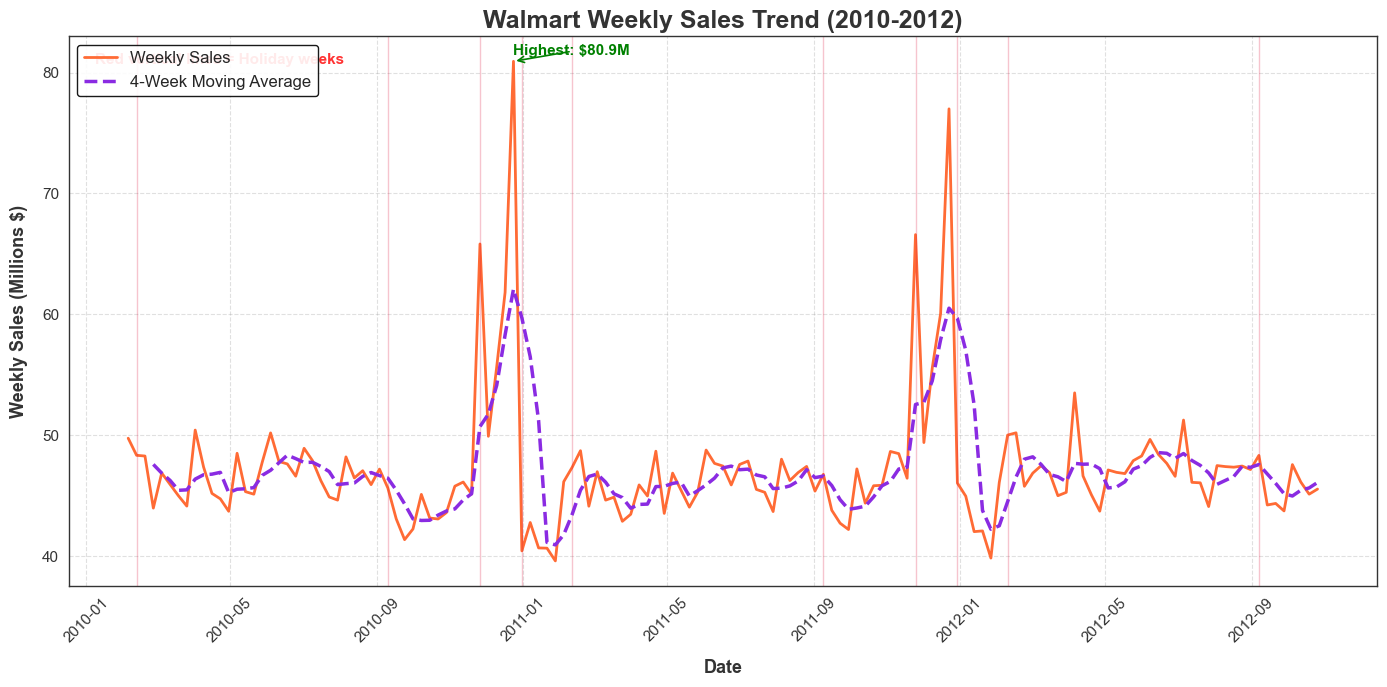

In [122]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

# CELL 12: VISUALIZATION 1 - SALES TREND OVER TIME
print("SALES TREND OVER TIME")
print("-" * 120)

# Create charts directory if it doesn't exist
if not os.path.exists('../charts'):
    os.makedirs('../charts')

# Prepare data for plotting
daily_total = df_clean.groupby('Date')['Weekly_Sales'].sum() / 1e6  # Convert to millions
holiday_dates = df_clean[df_clean['Holiday_Flag'] == 1]['Date'].unique()

# Create the plot
plt.figure(figsize=(14, 7))

# Plot the sales trend line (bright orange for visibility)
plt.plot(daily_total.index, daily_total.values, 
         color='#FF6B35', linewidth=2, label='Weekly Sales')

# Highlight holiday weeks with vertical lines (crimson red)
for date in holiday_dates:
    plt.axvline(x=date, color='#DC143C', alpha=0.25, linewidth=1)

# Add rolling average (purple dashed line)
rolling_avg = daily_total.rolling(window=4).mean()
plt.plot(rolling_avg.index, rolling_avg.values, 
         color='#8A2BE2', linewidth=2.5, linestyle='--', 
         label='4-Week Moving Average')

# Customize chart appearance
plt.title('Walmart Weekly Sales Trend (2010-2012)', fontsize=18, fontweight='bold', color='#333333')
plt.xlabel('Date', fontsize=13, fontweight='bold', color='#333333', labelpad=10)
plt.ylabel('Weekly Sales (Millions $)', fontsize=13, fontweight='bold', color='#333333', labelpad=10)

# Style ticks
plt.xticks(rotation=45, fontsize=11, color='#333333')
plt.yticks(fontsize=11, color='#333333')

# Style legend
plt.legend(loc='upper left', fontsize=12, framealpha=0.9, edgecolor='black')

# Style grid and spines
plt.grid(True, alpha=0.3, color='#999999', linestyle='--', linewidth=0.8)
for spine in plt.gca().spines.values():
    spine.set_color('#333333')
    spine.set_linewidth(1)

# Annotate highest sales week
max_date = daily_total.idxmax()
max_value = daily_total.max()
plt.annotate(f'Highest: ${max_value:.1f}M', 
             xy=(max_date, max_value), 
             xytext=(max_date, max_value + 0.5),
             arrowprops=dict(arrowstyle='->', color='green', lw=1.2),
             fontsize=11, color='green', fontweight='bold')

# Add holiday label note
plt.text(0.02, 0.95, 'Red vertical lines = Holiday weeks', 
         transform=plt.gca().transAxes, fontsize=11, 
         color='red', alpha=0.8, fontweight='bold')

plt.tight_layout()

# Save and show chart
plt.savefig('../charts/sales_trend.png', dpi=150, bbox_inches='tight')
plt.show()

### Top 10 Stores

TOP 10 STORES
------------------------------------------------------------------------------------------------------------------------


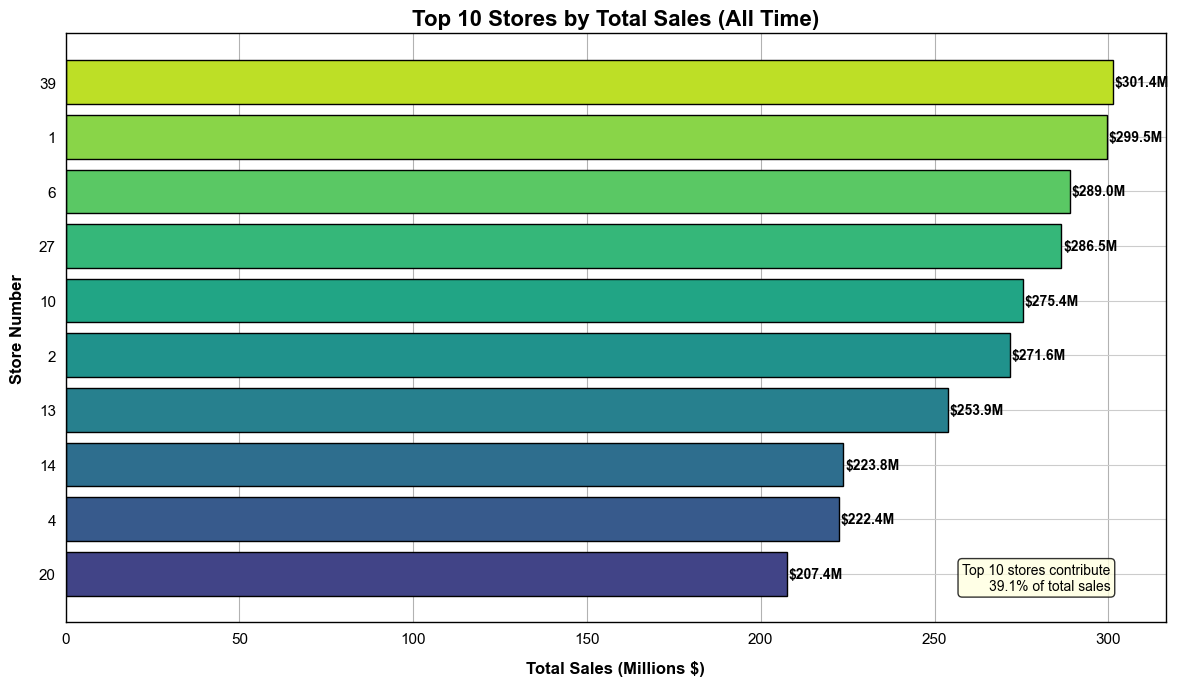

In [124]:
print("TOP 10 STORES")
print("-" * 120)

# Calculate total sales by store
store_sales = df_clean.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False)
top_10_stores = store_sales.head(10)

# Create the plot
plt.figure(figsize=(12, 7))

# Create vibrant color gradient for bars
colors = plt.cm.viridis(np.linspace(0.2, 0.9, 10))
bars = plt.barh(range(10, 0, -1), top_10_stores.values / 1e6, color=colors[::-1], edgecolor='black', linewidth=1)

# Add value labels on the bars
for i, (bar, value) in enumerate(zip(bars, top_10_stores.values / 1e6)):
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
             f'${value:.1f}M', ha='left', va='center', fontsize=10, fontweight='bold', color='black')

# Customize the chart with bold black axes
plt.title('Top 10 Stores by Total Sales (All Time)', fontsize=16, fontweight='bold', color='black')
plt.xlabel('Total Sales (Millions $)', fontsize=12, fontweight='bold', color='black', labelpad=10)
plt.ylabel('Store Number', fontsize=12, fontweight='bold', color='black', labelpad=10)

# Set tick colors to black
plt.yticks(range(1, 11), top_10_stores.index, fontsize=11, color='black')
plt.xticks(fontsize=11, color='black')

# Set grid to black color
plt.grid(axis='x', alpha=0.3, color='black', linestyle='-', linewidth=0.8)

# Set spines to black
for spine in plt.gca().spines.values():
    spine.set_color('black')
    spine.set_linewidth(1)

# Add annotation about concentration
total_sales_all = store_sales.sum() / 1e6
top10_sales = top_10_stores.sum() / 1e6
concentration = (top10_sales / total_sales_all) * 100
plt.text(0.95, 0.05, f'Top 10 stores contribute\n{concentration:.1f}% of total sales', 
         transform=plt.gca().transAxes, fontsize=10,
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8, edgecolor='black'),
         ha='right', va='bottom', color='black')

plt.tight_layout()

# Save the chart
plt.savefig('../charts/top_stores.png', dpi=150, bbox_inches='tight')
plt.show()

### Holiday vs Non-Holiday Sales

HOLIDAY VS NON-HOLIDAY SALES
------------------------------------------------------------------------------------------------------------------------


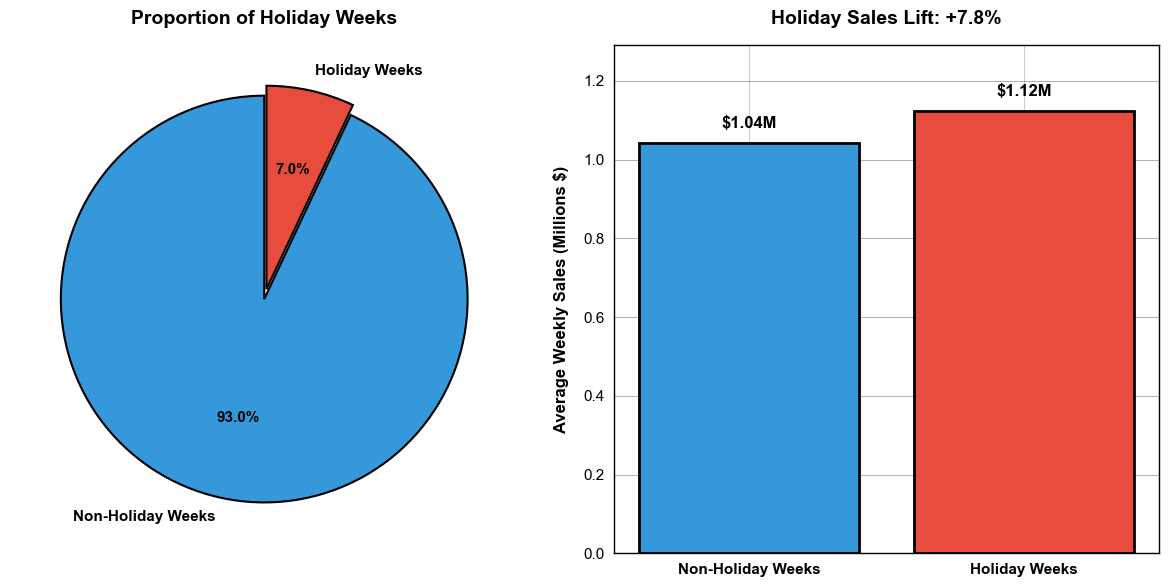

In [127]:
print("HOLIDAY VS NON-HOLIDAY SALES")
print("-" * 120)

# Calculate average sales for holiday and non-holiday weeks
holiday_avg = df_clean.groupby('Holiday_Flag')['Weekly_Sales'].mean() / 1e6
labels = ['Non-Holiday Weeks', 'Holiday Weeks']
colors = ['#3498db', '#e74c3c']

# Create the plot
plt.figure(figsize=(12, 6))

# Create pie chart for proportion
plt.subplot(1, 2, 1)
holiday_counts = df_clean['Holiday_Flag'].value_counts()
wedges, texts, autotexts = plt.pie(holiday_counts.values, labels=labels, autopct='%1.1f%%', 
        colors=colors, startangle=90, explode=(0, 0.05),
        textprops={'fontsize': 11, 'fontweight': 'bold', 'color': 'black'},
        wedgeprops={'edgecolor': 'black', 'linewidth': 1.5})

# Customize pie chart text colors
for text in texts:
    text.set_color('black')
    text.set_fontweight('bold')
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(11)

plt.title('Proportion of Holiday Weeks', fontsize=14, fontweight='bold', color='black', pad=15)

# Create bar chart for sales comparison
plt.subplot(1, 2, 2)
bars = plt.bar(labels, holiday_avg.values, color=colors, edgecolor='black', linewidth=2)

# Add value labels on bars
for bar, value in zip(bars, holiday_avg.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03, 
             f'${value:.2f}M', ha='center', va='bottom', fontsize=12, fontweight='bold', color='black')

# Calculate lift percentage
lift = ((holiday_avg[1] - holiday_avg[0]) / holiday_avg[0]) * 100
plt.title(f'Holiday Sales Lift: +{lift:.1f}%', fontsize=14, fontweight='bold', color='black', pad=15)
plt.ylabel('Average Weekly Sales (Millions $)', fontsize=12, fontweight='bold', color='black', labelpad=10)

# Set tick colors to black
plt.xticks(fontsize=11, color='black', fontweight='bold')
plt.yticks(fontsize=11, color='black')

# Set grid to black color
plt.grid(axis='y', alpha=0.3, color='black', linestyle='-', linewidth=0.8)

# Set spines to black
for spine in plt.gca().spines.values():
    spine.set_color('black')
    spine.set_linewidth(1)

# Set y-axis limit
plt.ylim(0, max(holiday_avg.values) * 1.15)

plt.tight_layout()

# Save the chart
plt.savefig('../charts/holiday_effect.png', dpi=150, bbox_inches='tight')
plt.show()

## Monthly Sales Pattern

MONTHLY SALES PATTERN
------------------------------------------------------------------------------------------------------------------------


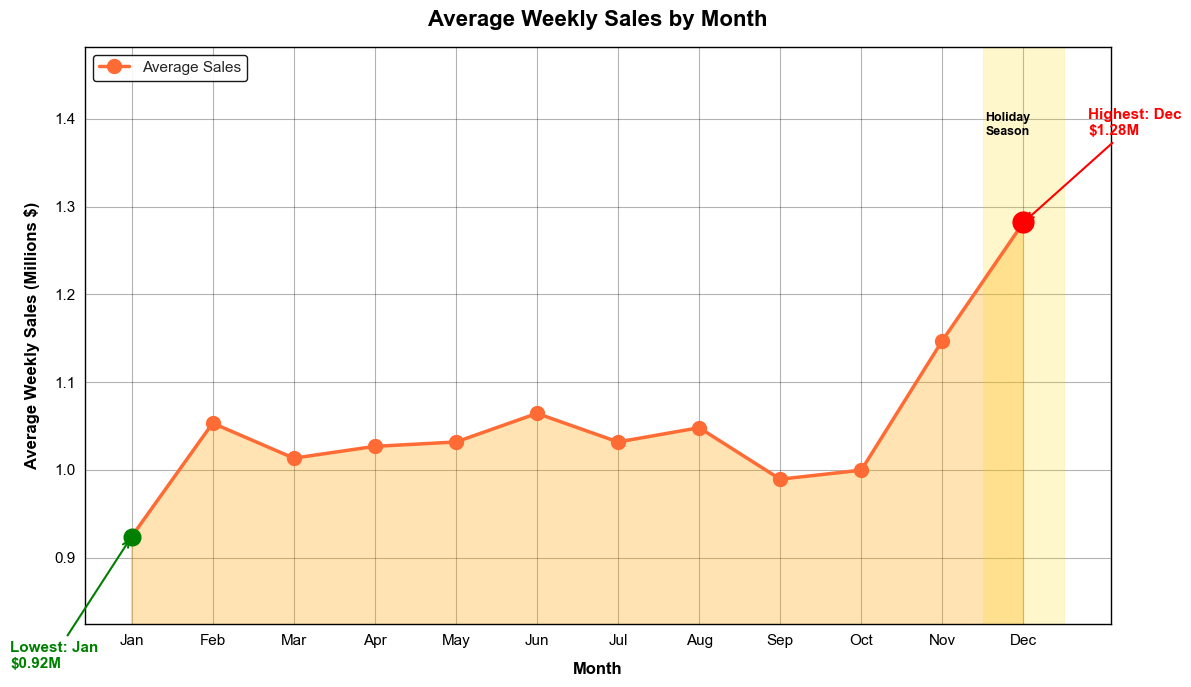

In [129]:
print("MONTHLY SALES PATTERN")
print("-" * 120)

# Calculate monthly averages
monthly_avg = df_clean.groupby('Month')['Weekly_Sales'].mean() / 1e6
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Create the plot
plt.figure(figsize=(12, 7))

# Line chart with markers
plt.plot(range(1, 13), monthly_avg.values, marker='o', linewidth=2.5, 
         markersize=10, color='#FF6B35', label='Average Sales')

# Fill area under the curve
plt.fill_between(range(1, 13), monthly_avg.values, alpha=0.3, color='#FFA500')

# Highlight the best month
best_month = monthly_avg.idxmax()
best_value = monthly_avg[best_month]
plt.plot(best_month, best_value, 'ro', markersize=15)
plt.annotate(f'Highest: {month_names[best_month-1]}\n${best_value:.2f}M', 
             xy=(best_month, best_value),
             xytext=(best_month + 0.8, best_value + 0.1),
             arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
             fontsize=11, fontweight='bold', color='red')

# Highlight the worst month
worst_month = monthly_avg.idxmin()
worst_value = monthly_avg[worst_month]
plt.plot(worst_month, worst_value, 'go', markersize=12)
plt.annotate(f'Lowest: {month_names[worst_month-1]}\n${worst_value:.2f}M', 
             xy=(worst_month, worst_value),
             xytext=(worst_month - 1.5, worst_value - 0.15),
             arrowprops=dict(arrowstyle='->', color='green', lw=1.5),
             fontsize=11, fontweight='bold', color='green')

# Customize the chart with bold black axes
plt.title('Average Weekly Sales by Month', fontsize=16, fontweight='bold', color='black', pad=15)
plt.xlabel('Month', fontsize=12, fontweight='bold', color='black', labelpad=10)
plt.ylabel('Average Weekly Sales (Millions $)', fontsize=12, fontweight='bold', color='black', labelpad=10)

# Set tick colors to black
plt.xticks(range(1, 13), month_names, fontsize=11, color='black')
plt.yticks(fontsize=11, color='black')

# Set grid to black color
plt.grid(True, alpha=0.3, color='black', linestyle='-', linewidth=0.8)

# Set spines to black
for spine in plt.gca().spines.values():
    spine.set_color('black')
    spine.set_linewidth(1)

# Set y-axis limits
plt.ylim(min(monthly_avg.values) - 0.1, max(monthly_avg.values) + 0.2)

# Add legend
plt.legend(loc='upper left', fontsize=11, framealpha=0.9, edgecolor='black')

# Add seasonal annotations
plt.axvspan(11.5, 12.5, alpha=0.2, color='gold', edgecolor='black', linewidth=0.5)
plt.text(11.8, plt.ylim()[1] - 0.1, 'Holiday\nSeason', ha='center', fontsize=9, 
         color='black', fontweight='bold')

plt.tight_layout()

# Save the chart
plt.savefig('../charts/monthly_pattern.png', dpi=150, bbox_inches='tight')
plt.show()

## Correlation Heatmap 

CORRELATION HEATMAP
------------------------------------------------------------------------------------------------------------------------


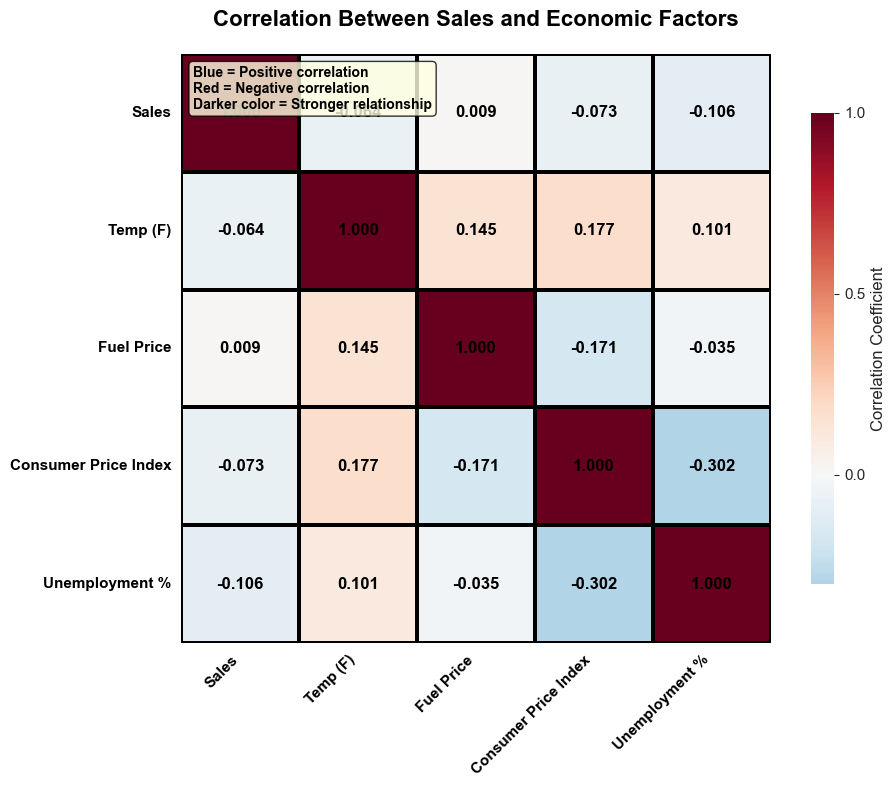

In [131]:
print("CORRELATION HEATMAP")
print("-" * 120)

# Prepare correlation matrix
numeric_cols = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
corr_matrix = df_clean[numeric_cols].corr()

# Create custom labels for better readability
label_map = {
    'Weekly_Sales': 'Sales',
    'Temperature': 'Temp (F)',
    'Fuel_Price': 'Fuel Price',
    'CPI': 'Consumer Price Index',
    'Unemployment': 'Unemployment %'
}
corr_matrix = corr_matrix.rename(index=label_map, columns=label_map)

# Create the plot
plt.figure(figsize=(10, 8))

# Create heatmap with custom formatting
sns.heatmap(corr_matrix, 
            annot=True,           
            cmap='RdBu_r',        # Red for negative, blue for positive (reversed for better contrast)
            center=0,             
            fmt='.3f',            
            square=True,          
            linewidths=1.5,       
            linecolor='black',    # Black lines between cells
            cbar_kws={'shrink': 0.8, 'label': 'Correlation Coefficient', 
                      'ticks': [-1, -0.5, 0, 0.5, 1]},
            annot_kws={'size': 12, 'weight': 'bold', 'color': 'black'})

# Customize the chart with bold black axes
plt.title('Correlation Between Sales and Economic Factors', fontsize=16, fontweight='bold', color='black', pad=20)

# Set tick colors to black
plt.xticks(rotation=45, ha='right', fontsize=11, color='black', fontweight='bold')
plt.yticks(rotation=0, fontsize=11, color='black', fontweight='bold')

# Set spines to black
for spine in plt.gca().spines.values():
    spine.set_color('black')
    spine.set_linewidth(1)

# Add annotation box with interpretation (no emojis)
plt.text(0.02, 0.98, 
         'Blue = Positive correlation\nRed = Negative correlation\nDarker color = Stronger relationship', 
         transform=plt.gca().transAxes, fontsize=10,
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8, edgecolor='black'),
         verticalalignment='top', color='black', fontweight='bold')

plt.tight_layout()

# Save the chart
plt.savefig('../charts/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Temperature vs Sales

TEMPERATURE VS SALES
------------------------------------------------------------------------------------------------------------------------


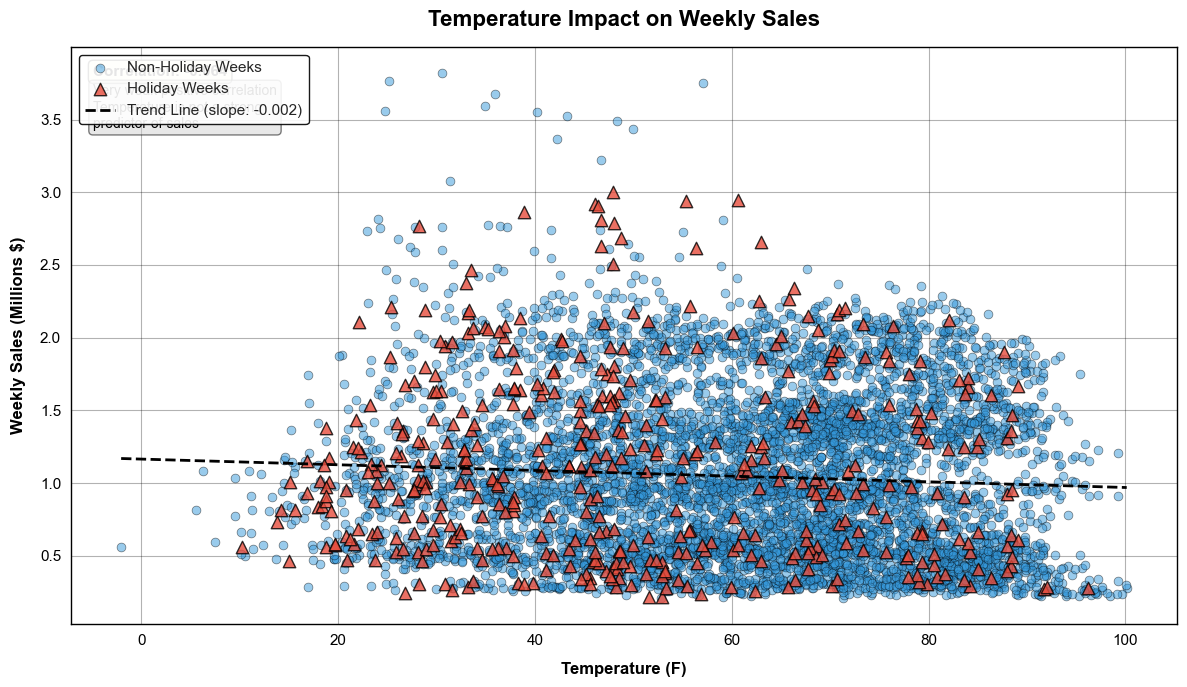

In [ ]:
print("TEMPERATURE VS SALES")
print("-" * 120)


# Create the plot
plt.figure(figsize=(12, 7))

# Separate data by holiday status
holiday_mask = df_clean['Holiday_Flag'] == 1

# Scatter plot for non-holiday weeks
plt.scatter(df_clean[~holiday_mask]['Temperature'], 
            df_clean[~holiday_mask]['Weekly_Sales'] / 1e6, 
            alpha=0.5, color='#3498db', label='Non-Holiday Weeks', s=40, edgecolors='black', linewidth=0.5)

# Scatter plot for holiday weeks
plt.scatter(df_clean[holiday_mask]['Temperature'], 
            df_clean[holiday_mask]['Weekly_Sales'] / 1e6, 
            alpha=0.8, color='#e74c3c', label='Holiday Weeks', s=80, marker='^', edgecolors='black', linewidth=1)

# Add trend line for all data
z = np.polyfit(df_clean['Temperature'], df_clean['Weekly_Sales'] / 1e6, 1)
p = np.poly1d(z)
x_trend = np.linspace(df_clean['Temperature'].min(), df_clean['Temperature'].max(), 100)
plt.plot(x_trend, p(x_trend), '--', color='black', linewidth=2, label=f'Trend Line (slope: {z[0]:.3f})')

# Customize the chart with bold black axes
plt.title('Temperature Impact on Weekly Sales', fontsize=16, fontweight='bold', color='black', pad=15)
plt.xlabel('Temperature (F)', fontsize=12, fontweight='bold', color='black', labelpad=10)
plt.ylabel('Weekly Sales (Millions $)', fontsize=12, fontweight='bold', color='black', labelpad=10)

# Set tick colors to black
plt.xticks(fontsize=11, color='black')
plt.yticks(fontsize=11, color='black')

# Set grid to black color
plt.grid(True, alpha=0.3, color='black', linestyle='-', linewidth=0.8)

# Set spines to black
for spine in plt.gca().spines.values():
    spine.set_color('black')
    spine.set_linewidth(1)

# Add legend with black edge
plt.legend(loc='upper left', fontsize=11, framealpha=0.9, edgecolor='black')

# Add correlation annotation
corr_value = df_clean['Weekly_Sales'].corr(df_clean['Temperature'])
plt.text(0.02, 0.95, f'Correlation: {corr_value:.3f}', 
         transform=plt.gca().transAxes, fontsize=11, fontweight='bold', color='black',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8, edgecolor='black'))

# Add interpretation
plt.text(0.02, 0.86, 'Very weak positive correlation\nTemperature is not a strong\npredictor of sales', 
         transform=plt.gca().transAxes, fontsize=10, color='black',
         bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.5, edgecolor='black'))

plt.tight_layout()

# Save the chart
plt.savefig('../charts/temp_vs_sales.png', dpi=150, bbox_inches='tight')
plt.show()
